In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["STIXGeneral"]
mpl.rcParams["mathtext.fontset"] = "stix"


def load_nifti(path):
    """
    Load a NIfTI file and return the data array.
    """
    path = Path(path)
    return nib.load(str(path)).get_fdata()


def get_slice(volume, slice_idx, axis=2):
    """
    Extract a 2D slice from a 3D volume.
    """
    if volume.ndim != 3:
        raise ValueError(f"Expected 3D volume, got shape {volume.shape}")

    if axis < 0 or axis > 2:
        raise ValueError("axis must be 0, 1, or 2")

    if slice_idx < 0 or slice_idx >= volume.shape[axis]:
        raise ValueError(
            f"slice_idx={slice_idx} is out of bounds for axis={axis} "
            f"with size {volume.shape[axis]}"
        )

    if axis == 0:
        return volume[slice_idx, :, :]
    if axis == 1:
        return volume[:, slice_idx, :]
    return volume[:, :, slice_idx]


def normalize_for_display(img):
    """
    Normalize image intensities to [0, 1] for display.
    """
    img = img.astype(np.float32)
    vmin = np.percentile(img, 1)
    vmax = np.percentile(img, 99)

    if vmax <= vmin:
        return np.zeros_like(img, dtype=np.float32)

    img = np.clip(img, vmin, vmax)
    img = (img - vmin) / (vmax - vmin)
    return img


def make_overlay(
    base_img,
    mask=None,
    pred=None,
    alpha_gt=0.45,
    alpha_pred_only=0.45,
    alpha_overlap=0.60,
):
    """
    Standard overlay on grayscale brain.

    Colors:
    - GT only: red
    - prediction only: yellow
    - overlap: green
    """
    base = normalize_for_display(base_img)
    rgb = np.stack([base, base, base], axis=-1)

    mask_bin = (
        (mask > 0).astype(np.float32)
        if mask is not None
        else np.zeros(base.shape, dtype=np.float32)
    )
    pred_bin = (
        (pred > 0).astype(np.float32)
        if pred is not None
        else np.zeros(base.shape, dtype=np.float32)
    )

    gt_only = (mask_bin > 0) & (pred_bin == 0)
    pred_only = (pred_bin > 0) & (mask_bin == 0)
    overlap = (mask_bin > 0) & (pred_bin > 0)

    # GT only -> red
    rgb[..., 0] = np.where(
        gt_only,
        np.clip(rgb[..., 0] + alpha_gt, 0, 1),
        rgb[..., 0],
    )

    # Prediction only -> yellow (red + green)
    rgb[..., 0] = np.where(
        pred_only,
        np.clip(rgb[..., 0] + alpha_pred_only, 0, 1),
        rgb[..., 0],
    )
    rgb[..., 1] = np.where(
        pred_only,
        np.clip(rgb[..., 1] + alpha_pred_only, 0, 1),
        rgb[..., 1],
    )

    # Overlap -> green
    rgb[..., 0] = np.where(overlap, 0.0, rgb[..., 0])
    rgb[..., 1] = np.where(overlap, 1.0, rgb[..., 1])
    rgb[..., 2] = np.where(overlap, 0.0, rgb[..., 2])

    return np.clip(rgb, 0, 1)


def make_overlay_faint_brain(
    base_img,
    mask=None,
    pred=None,
    brain_alpha=0.20,
):
    """
    Overlay with faint brain background.

    Colors:
    - GT only: red
    - prediction only: yellow
    - overlap: green
    """
    base = normalize_for_display(base_img)
    base = brain_alpha * base + (1.0 - brain_alpha) * 1.0
    rgb = np.stack([base, base, base], axis=-1)

    mask_bin = (
        (mask > 0).astype(np.float32)
        if mask is not None
        else np.zeros(base.shape, dtype=np.float32)
    )
    pred_bin = (
        (pred > 0).astype(np.float32)
        if pred is not None
        else np.zeros(base.shape, dtype=np.float32)
    )

    gt_only = (mask_bin > 0) & (pred_bin == 0)
    pred_only = (pred_bin > 0) & (mask_bin == 0)
    overlap = (mask_bin > 0) & (pred_bin > 0)

    # GT only -> red
    rgb[..., 0] = np.where(gt_only, 1.0, rgb[..., 0])
    rgb[..., 1] = np.where(gt_only, 0.0, rgb[..., 1])
    rgb[..., 2] = np.where(gt_only, 0.0, rgb[..., 2])

    # Prediction only -> yellow
    rgb[..., 0] = np.where(pred_only, 1.0, rgb[..., 0])
    rgb[..., 1] = np.where(pred_only, 1.0, rgb[..., 1])
    rgb[..., 2] = np.where(pred_only, 0.0, rgb[..., 2])

    # Overlap -> green
    rgb[..., 0] = np.where(overlap, 0.0, rgb[..., 0])
    rgb[..., 1] = np.where(overlap, 1.0, rgb[..., 1])
    rgb[..., 2] = np.where(overlap, 0.0, rgb[..., 2])

    return np.clip(rgb, 0, 1)


def make_mask_only_overlay(mask=None, pred=None):
    """
    Create mask-only RGB image on black background.

    Colors:
    - GT only: red
    - prediction only: yellow
    - overlap: green
    """
    if mask is None and pred is None:
        raise ValueError("At least one of mask or pred must be provided.")

    shape = mask.shape if mask is not None else pred.shape
    rgb = np.zeros((*shape, 3), dtype=np.float32)

    mask_bin = (
        (mask > 0).astype(np.float32)
        if mask is not None
        else np.zeros(shape, dtype=np.float32)
    )
    pred_bin = (
        (pred > 0).astype(np.float32)
        if pred is not None
        else np.zeros(shape, dtype=np.float32)
    )

    gt_only = (mask_bin > 0) & (pred_bin == 0)
    pred_only = (pred_bin > 0) & (mask_bin == 0)
    overlap = (mask_bin > 0) & (pred_bin > 0)

    # GT only -> red
    rgb[..., 0] = np.where(gt_only, 1.0, rgb[..., 0])

    # Prediction only -> yellow
    rgb[..., 0] = np.where(pred_only, 1.0, rgb[..., 0])
    rgb[..., 1] = np.where(pred_only, 1.0, rgb[..., 1])

    # Overlap -> green
    rgb[..., 0] = np.where(overlap, 0.0, rgb[..., 0])
    rgb[..., 1] = np.where(overlap, 1.0, rgb[..., 1])
    rgb[..., 2] = np.where(overlap, 0.0, rgb[..., 2])

    return np.clip(rgb, 0, 1)


def prepare_case_slices(
    flair_path,
    gt_mask_path,
    catmil_path,
    dicece_path,
    tversky_path,
    focaltversky_path,
    slice_idx=90,
    axis=2,
    rotate_k=1,
):
    """
    Load all files and extract aligned 2D slices.
    """
    flair = load_nifti(flair_path)
    gt = load_nifti(gt_mask_path)
    catmil = load_nifti(catmil_path)
    dicece = load_nifti(dicece_path)
    tversky = load_nifti(tversky_path)
    focaltversky = load_nifti(focaltversky_path)

    shapes = {
        "FLAIR": flair.shape,
        "GT": gt.shape,
        "CATMIL": catmil.shape,
        "DiceCE": dicece.shape,
        "Tversky": tversky.shape,
        "FocalTversky": focaltversky.shape,
    }

    unique_shapes = set(shapes.values())
    if len(unique_shapes) != 1:
        raise ValueError(f"Volumes do not have the same shape: {shapes}")

    flair_sl = get_slice(flair, slice_idx, axis=axis)
    gt_sl = get_slice(gt, slice_idx, axis=axis)
    catmil_sl = get_slice(catmil, slice_idx, axis=axis)
    dicece_sl = get_slice(dicece, slice_idx, axis=axis)
    tversky_sl = get_slice(tversky, slice_idx, axis=axis)
    focaltversky_sl = get_slice(focaltversky, slice_idx, axis=axis)

    flair_sl = np.rot90(flair_sl, k=rotate_k)
    gt_sl = np.rot90(gt_sl, k=rotate_k)
    catmil_sl = np.rot90(catmil_sl, k=rotate_k)
    dicece_sl = np.rot90(dicece_sl, k=rotate_k)
    tversky_sl = np.rot90(tversky_sl, k=rotate_k)
    focaltversky_sl = np.rot90(focaltversky_sl, k=rotate_k)

    return {
        "flair": flair_sl,
        "gt": gt_sl,
        "catmil": catmil_sl,
        "dicece": dicece_sl,
        "tversky": tversky_sl,
        "focaltversky": focaltversky_sl,
    }


def plot_segmentation_comparison_single_figure(
    flair_path,
    gt_mask_path,
    catmil_path,
    dicece_path,
    tversky_path,
    focaltversky_path,
    slice_idx=90,
    axis=2,
    rotate_k=1,
    figsize=(12, 8),
    display_mode="faint_brain",
    case_id=None,
    save_path=None,
    dpi=1200,
):
    """
    Plot everything in one figure and optionally save to JPEG.

    display_mode:
    - "faint_brain": faint anatomy + GT/pred overlays
    - "mask_only": mask-only comparison on black background
    - "overlay": standard overlay on full brain image
    """
    data = prepare_case_slices(
        flair_path=flair_path,
        gt_mask_path=gt_mask_path,
        catmil_path=catmil_path,
        dicece_path=dicece_path,
        tversky_path=tversky_path,
        focaltversky_path=focaltversky_path,
        slice_idx=slice_idx,
        axis=axis,
        rotate_k=rotate_k,
    )

    flair_sl = data["flair"]
    gt_sl = data["gt"]
    catmil_sl = data["catmil"]
    dicece_sl = data["dicece"]
    tversky_sl = data["tversky"]
    focaltversky_sl = data["focaltversky"]

    flair_disp = normalize_for_display(flair_sl)
    gt_disp = (gt_sl > 0).astype(np.float32)

    if display_mode == "faint_brain":
        make_panel = lambda pred: make_overlay_faint_brain(
            flair_sl,
            mask=gt_sl,
            pred=pred,
        )
    elif display_mode == "mask_only":
        make_panel = lambda pred: make_mask_only_overlay(
            mask=gt_sl,
            pred=pred,
        )
    elif display_mode == "overlay":
        make_panel = lambda pred: make_overlay(
            flair_sl,
            mask=gt_sl,
            pred=pred,
        )
    else:
        raise ValueError(
            "display_mode must be one of: "
            "'faint_brain', 'mask_only', 'overlay'"
        )

    panels = [
        (f"{case_id}_FLAIR" if case_id else "FLAIR", flair_disp, "gray"),
        ("Ground Truth", gt_disp, "gray"),
        ("nnUNet-DiceCE", make_panel(dicece_sl), None),
        ("nnUNet-Tversky", make_panel(tversky_sl), None),
        ("nnUNet-FocalTversky", make_panel(focaltversky_sl), None),
        ("nnUNet-CATMIL", make_panel(catmil_sl), None),
    ]

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()

    for ax, (title, img, cmap) in zip(axes, panels):
        if cmap is None:
            ax.imshow(img)
        else:
            ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            save_path,
            format="jpeg",
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0.02,
        )

    plt.show()
    plt.close(fig)


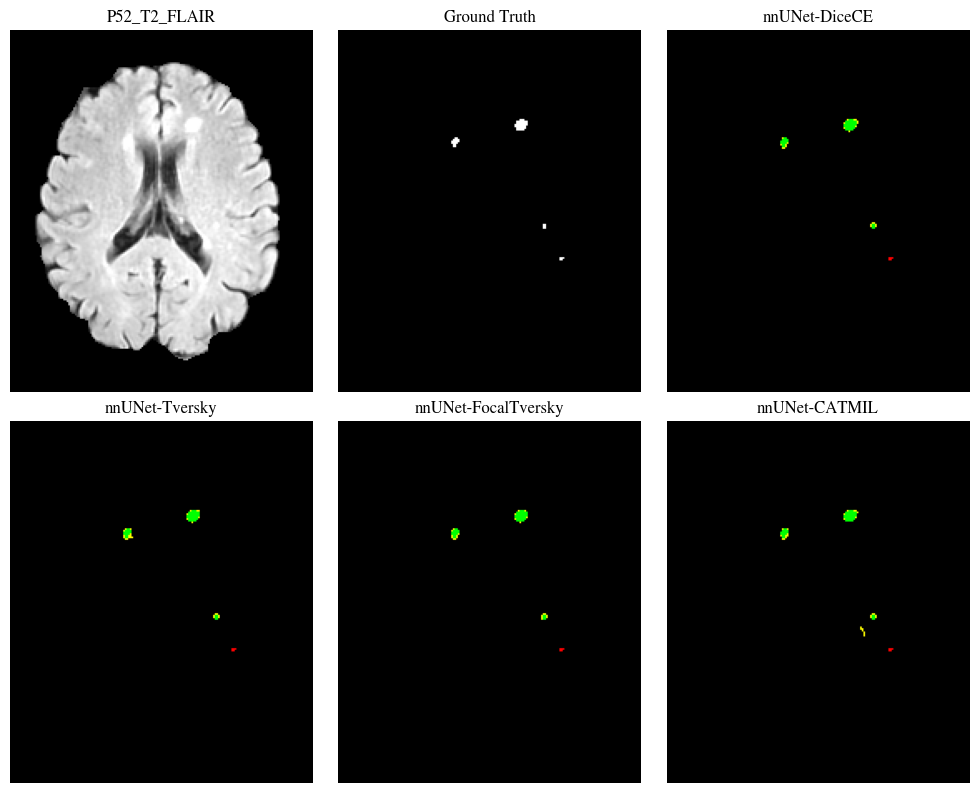

In [11]:
case_id = "P52_T2"
modality = "0003"
fold = 0
slice_idx = 87

data_root = "/media/storage/luu/nnUNet_raw/Dataset333_MSLesSeg"
pred_root = "/media/storage/luu/SmallLesionMRI/MSLesSeg/final_checkpoints"
out_dir = "/media/storage/luu/SmallLesionMRI/MSLesSeg/qualitative_figures"

flair_path = f"{data_root}/imagesTs/{case_id}_{modality}.nii.gz"
gt_mask_path = f"{data_root}/labelsTs/{case_id}.nii.gz"
catmil_path = f"{pred_root}/CATMIL/fold_{fold}/{case_id}.nii.gz"
dicece_path = f"{pred_root}/nnUNet/fold_{fold}/{case_id}.nii.gz"
tversky_path = f"{pred_root}/Tversky/fold_{fold}/{case_id}.nii.gz"
focaltversky_path = (
    f"{pred_root}/FocalTversky/fold_{fold}/{case_id}.nii.gz"
)

save_path = (
    f"{out_dir}/{case_id}_fold{fold}_slice{slice_idx}_segmentation_comparison.jpeg"
)

plot_segmentation_comparison_single_figure(
    flair_path=flair_path,
    gt_mask_path=gt_mask_path,
    catmil_path=catmil_path,
    dicece_path=dicece_path,
    tversky_path=tversky_path,
    focaltversky_path=focaltversky_path,
    slice_idx=slice_idx,
    axis=2,
    rotate_k=1,
    figsize=(10, 8),
    display_mode="mask_only",  # "mask_only", "faint_brain", or "overlay"
    case_id=case_id,
    save_path=save_path,
    dpi=1200,
)